# EDA: Human decisions vs. LLM-judge preferences over explanations
### AI-generated-text detection task (Reddit social media)

**Project context** (see `Decision_Calibrated_CoT (6).pdf`): we want to RL-train an LLM to produce
explanations ("Look for ..." hints) that lead *humans* to more accurate decisions. As a baseline we
will compare against an RL model trained on ordinary (LLM-judge) preferences. This notebook asks:

1. **How did humans actually do on the task**, overall and per explanation source?
2. **How reliable are the decision accuracy labels** — the per-text designation of which explanation led to
   more accurate human decisions — given tiny per-explanation samples?
3. **What do the LLM judges prefer**, and how much do their preferences agree with what actually helped humans?

**Scope note:** this repository contains data for **one task only** — AI/Human text detection on
Reddit posts (`social/`). There is no political-party data here.

**Data files**

| File | What it is |
|---|---|
| `preference_data/human_preferred_explanations.json` | 2,978 entries; for each text, the explanation that yielded higher human accuracy (with per-arm accuracy & decision counts) |
| `preference_data/preference_pairs_aggregated.json` | 4,520 entries; the explanation preferred by majority vote of 3 LLM judges (Qwen, Gemma, Llama) — **one vote per judge, no repetitions** |
| `social/master_stimuli_database_socialmedia.csv` | maps each text to its two competing explanations (D1/D2) |
| `social/SocialMedia_*` | raw texts and explanation files |

**Structure of the comparison:** each of 2,260 human-written Reddit texts and 2,260 AI rewrites was
paired with exactly **two** explanations drawn from three sources: `explanation` (base),
`explanation_claude`, `explanation_gemini`. The LLM judges saw both explanations and voted for one —
a genuine preference judgment. **Humans never compared explanations**: each participant saw the text
with *one* of the two explanations and simply made the AI/Human call. What the "human-preferred"
file records is therefore a **decision accuracy label** — which of the two explanations had the higher
observed decision accuracy among its (few) readers — not a rating or choice anyone expressed.

> ⚠️ **The big caveat, up front:** most explanations received only **1–2 human decisions**. Item-level
> decision accuracy labels are therefore extremely noisy, and we quantify that noise before comparing
> against the LLM judges. Additionally, the human-preference file **excludes** texts where the
> only observed arm had accuracy < 0.5 (see §1.2), which biases naive accuracy estimates upward.

In [28]:
import json, re, itertools, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path.cwd()

# ---- palette / chart style (validated default palette, light mode) ----
PAL = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
       "yellow": "#eda100", "magenta": "#e87ba4", "green": "#008300",
       "violet": "#4a3aa7", "red": "#e34948"}
SURFACE, INK, INK2, MUTED, GRID, BASELINE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
FAMILY_COLOR = {"base": PAL["blue"], "claude": PAL["orange"], "gemini": PAL["aqua"]}  # fixed, never cycled

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.labelcolor": INK2, "axes.titlecolor": INK, "font.size": 11,
    "font.family": "sans-serif",
})

hp = json.load(open(ROOT / "human_preferred_explanations.json"))
mp = json.load(open(ROOT / "preference_pairs_aggregated.json"))
master = pd.read_csv("/projects/p32143/RL_human_decision/text_data/social/master_stimuli_database_socialmedia.csv")

def family(source):
    '''Map a source dir name to its explanation family.'''
    if source.endswith("_claude"): return "claude"
    if source.endswith("_gemini"): return "gemini"
    return "base"

def wilson_ci(k, n, z=1.959964):
    '''95% Wilson score interval for a binomial proportion.'''
    if n == 0: return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (center - half, center + half)

print(f"human-preference entries: {len(hp):,}   LLM-preference entries: {len(mp):,}   master rows: {len(master):,}")

human-preference entries: 3,091   LLM-preference entries: 4,520   master rows: 9,040


## 1. Data inventory & integrity

### 1.1 Basic structure and sample sizes

Each human-preference file entry describes one text — a human-written post or an AI rewrite, keyed as
`<text_id>_<human|ai>` — with two "arms"
(the chosen and the rejected explanation), each carrying an observed accuracy and a decision count.

In [29]:
rows = []
for key, v in hp.items():
    text_id, version = key.rsplit("_", 1)
    for arm in ("chosen", "rejected"):
        src = v[f"{arm}_explanation_source"] if f"{arm}_explanation_source" in v else v[f"{arm}_source"]
        acc, n = v[f"{arm}_accuracy"], v[f"{arm}_decisions_count"]
        k = int(round(acc * n)) if (acc is not None and n) else (0 if n == 0 else None)
        rows.append(dict(key=key, text_id=text_id, version=version, label=v["label"], arm=arm,
                         source=src, family=family(src), n=n, correct=k,
                         accuracy=acc, method=v["decision_method"]))
arms = pd.DataFrame(rows)

total_decisions = arms["n"].sum()
print(f"total human decisions recorded: {total_decisions:,}")
print(f"texts covered by human data: {len(hp):,} of {len(mp):,} ({len(hp)/len(mp):.1%})")
print()
print("decisions per explanation arm:")
print(arms["n"].value_counts().sort_index().to_frame("arms").assign(pct=lambda d: (d.arms/len(arms)).round(3)))

total human decisions recorded: 9,361
texts covered by human data: 3,091 of 4,520 (68.4%)

decisions per explanation arm:
   arms    pct
n             
0  1571  0.254
1   366  0.059
2  3824  0.619
3   349  0.056
4    63  0.010
5     7  0.001
6     1  0.000
7     1  0.000


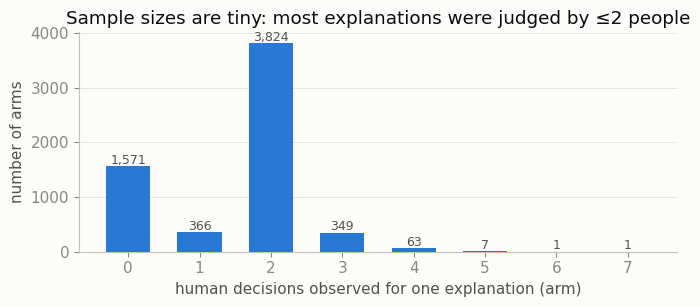

93.2% of arms have ≤2 decisions; median = 2


In [30]:
fig, ax = plt.subplots(figsize=(7, 3.2))
dist = arms["n"].value_counts().sort_index()
ax.bar(dist.index, dist.values, width=0.62, color=PAL["blue"], zorder=3)
for x, y in dist.items():
    ax.text(x, y + 40, f"{y:,}", ha="center", fontsize=9, color=INK2)
ax.set_xlabel("human decisions observed for one explanation (arm)")
ax.set_ylabel("number of arms")
ax.set_title("Sample sizes are tiny: most explanations were judged by ≤2 people")
ax.set_xticks(dist.index)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

share_le2 = (arms["n"] <= 2).mean()
print(f"{share_le2:.1%} of arms have ≤2 decisions; median = {int(arms['n'].median())}")

### 1.2 Integrity checks and a selection-bias warning

Three things worth knowing before any modeling:

1. **Pair consistency across files.** The (chosen, rejected) source pair in the human file should
   match the pair the LLM judges saw for the same text.
2. **Same-source pairs.** Some LLM entries compare two explanations from the *same* source directory
   (a pipeline quirk — the D1/D2 pairing occasionally drew both explanations from one source).
3. **Coverage is not random.** The human file's `decision_method` values imply the inclusion rule:
   a text enters the file only if *both* arms have data, or the single observed arm has
   accuracy ≥ 0.5. Texts where the only observed arm had accuracy **< 0.5 were silently
   dropped** — so pooled accuracy computed from this file is an **overestimate** of true human accuracy.

In [31]:
mismatched, same_source_mp = [], []
for key, v in mp.items():
    pair_mp = {v["chosen_source"]} | {r["source"] for r in v["rejected_explanations"]}
    if len(pair_mp) == 1:
        same_source_mp.append(key)
    if key in hp:
        h = hp[key]
        pair_hp = {h["chosen_explanation_source"], h["rejected_explanation_source"]}
        if pair_hp != pair_mp:
            mismatched.append(key)

print(f"LLM entries comparing two explanations from the SAME source: {len(same_source_mp)}")
print(f"entries whose source pair differs between the two files:     {len(mismatched)}")
print(f"decision_method breakdown:")
print(arms.drop_duplicates('key')['method'].value_counts().to_frame('entries'))

# entries excluded from agreement analyses later
EXCLUDE = set(mismatched) | set(same_source_mp)
print(f"\nentries excluded from human-vs-LLM agreement analyses: {len(EXCLUDE & set(hp))} of {len(hp)}")

LLM entries comparing two explanations from the SAME source: 85
entries whose source pair differs between the two files:     60
decision_method breakdown:
                                      entries
method                                       
both_have_data_higher_accuracy           1038
only_second_has_data_above_threshold      787
only_first_has_data_above_threshold       784
both_have_data_tied_more_samples          482

entries excluded from human-vs-LLM agreement analyses: 60 of 3091


> **Decision flagged:** in all human-vs-LLM agreement analyses below we exclude the entries with
> mismatched or same-source pairs (the preference is ill-defined there). All other analyses use the
> full data. Revisit if you'd rather resolve the mismatches from the raw logs.

## 2. How did humans do on the task?

### 2.1 Overall accuracy

The README reports "mean accuracy 0.742" — but that is the mean over **chosen arms only**, i.e., the
max of two noisy accuracies. That's selection bias on several levels (max-of-two, plus the coverage rule in
§1.2). Pooling all decisions across both arms is the real estimate — and even it is biased upward
by the coverage rule.

In [32]:
d = arms.dropna(subset=["correct"]).query("n > 0")
k_all, n_all = int(d["correct"].sum()), int(d["n"].sum())
lo, hi = wilson_ci(k_all, n_all)
print(f"pooled human accuracy (all arms):   {k_all/n_all:.3f}  [95% CI {lo:.3f}–{hi:.3f}]  (n={n_all:,} decisions)")

chosen_mean = arms.query("arm=='chosen'")["accuracy"].mean()
print(f"README-style mean of chosen-arm accuracies: {chosen_mean:.3f}   <- selection-biased, do not use")

# binomial test vs chance
res = stats.binomtest(k_all, n_all, 0.5)
print(f"vs. chance (0.5): p = {res.pvalue:.2e}")

pooled human accuracy (all arms):   0.577  [95% CI 0.567–0.587]  (n=9,361 decisions)
README-style mean of chosen-arm accuracies: 0.708   <- selection-biased, do not use
vs. chance (0.5): p = 7.80e-51


**Humans are only modestly better than chance (~0.58–0.59)** at telling human-written from
AI-rewritten Reddit posts, even with an explanation hint — and the true number is somewhat lower
because low-accuracy singletons were dropped from this file. The headroom between ~0.58 and ceiling is what decision-calibrated explanations can try to capture.

### 2.2 Accuracy by true label and by explanation source

`Reddit*` sources are only ever shown with human-written texts and `rewrite*` sources with
AI-generated texts, so "source directory" = family × text type.

In [33]:
def pooled(df):
    k, n = int(df["correct"].sum()), int(df["n"].sum())
    lo, hi = wilson_ci(k, n)
    return pd.Series(dict(correct=k, n=n, acc=k/n if n else np.nan, lo=lo, hi=hi))

by_label = d.groupby("label").apply(pooled, include_groups=False)
print("accuracy by true label of the text:")
print(by_label.round(3), "\n")

by_src = d.groupby(["label", "family"]).apply(pooled, include_groups=False).reset_index()
print("accuracy by text label x explanation family:")
print(by_src.round(3))

accuracy by true label of the text:
       correct       n    acc     lo     hi
label                                      
AI      2502.0  4557.0  0.549  0.535  0.563
Human   2903.0  4804.0  0.604  0.590  0.618 

accuracy by text label x explanation family:
   label  family  correct       n    acc     lo     hi
0     AI    base    976.0  1703.0  0.573  0.549  0.596
1     AI  claude    938.0  1771.0  0.530  0.506  0.553
2     AI  gemini    588.0  1083.0  0.543  0.513  0.572
3  Human    base   1132.0  1882.0  0.601  0.579  0.623
4  Human  claude    915.0  1524.0  0.600  0.576  0.625
5  Human  gemini    856.0  1398.0  0.612  0.586  0.638


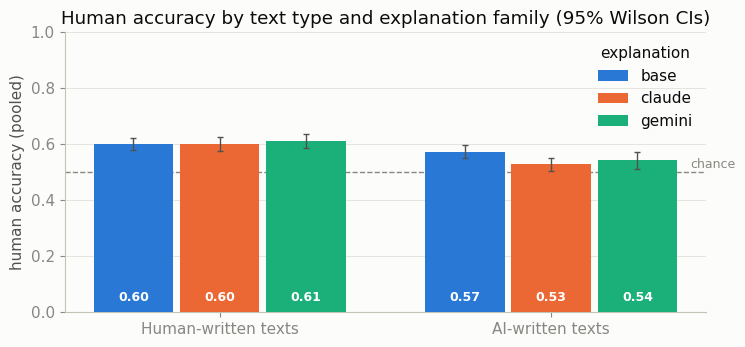

In [34]:
fig, ax = plt.subplots(figsize=(7.6, 3.6))
fams = ["base", "claude", "gemini"]
labels_order = ["Human", "AI"]
w = 0.24
for j, fam in enumerate(fams):
    sub = by_src.set_index(["label", "family"])
    xs, ys, errs = [], [], []
    for i, lab in enumerate(labels_order):
        r = sub.loc[(lab, fam)]
        xs.append(i + (j - 1) * (w + 0.02)); ys.append(r["acc"])
        errs.append([r["acc"] - r["lo"], r["hi"] - r["acc"]])
    ax.bar(xs, ys, width=w, color=FAMILY_COLOR[fam], label=fam, zorder=3)
    ax.errorbar(xs, ys, yerr=np.array(errs).T, fmt="none", ecolor=INK2, elinewidth=1, capsize=2, zorder=4)
    for x, y in zip(xs, ys):
        ax.text(x, 0.04, f"{y:.2f}", ha="center", fontsize=9, color="#ffffff", fontweight="bold")
ax.axhline(0.5, color=MUTED, linewidth=1, linestyle="--", zorder=2)
ax.text(1.42, 0.505, "chance", fontsize=9, color=MUTED, va="bottom")
ax.set_xticks(range(len(labels_order)))
ax.set_xticklabels([f"{l}-written texts" for l in labels_order])
ax.set_ylabel("human accuracy (pooled)")
ax.set_ylim(0, 1)
ax.set_title("Human accuracy by text type and explanation family (95% Wilson CIs)")
ax.legend(title="explanation", frameon=False, loc="upper right")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### 2.3 Why item-level "preferences" are noisy

With n ≤ 2, an arm's observed accuracy can only be 0, ½, or 1. The distribution below is what
 small-sample granularity looks like, and shouldn't be read as a indicative of great/terrible explanations.

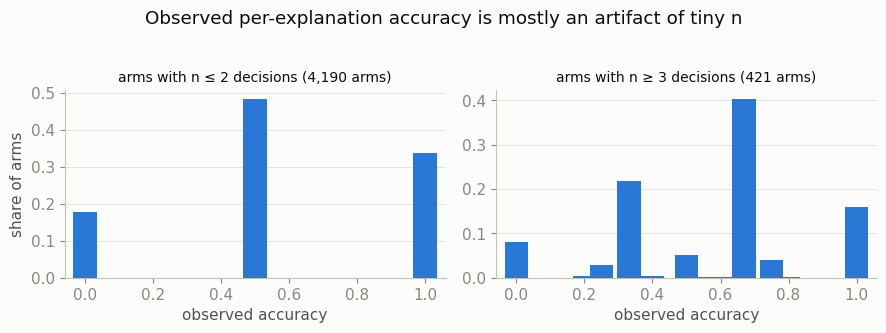

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=False)
for ax, nmax, title in [(axes[0], 2, "arms with n ≤ 2 decisions"), (axes[1], 99, "arms with n ≥ 3 decisions")]:
    sub = d[(d["n"] <= 2) if nmax == 2 else (d["n"] >= 3)]
    vc = sub["accuracy"].round(2).value_counts(normalize=True).sort_index()
    ax.bar(vc.index.astype(float), vc.values, width=0.07, color=PAL["blue"], zorder=3)
    ax.set_title(f"{title} ({len(sub):,} arms)", fontsize=10)
    ax.set_xlabel("observed accuracy"); ax.set_xlim(-0.06, 1.06)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("share of arms")
fig.suptitle("Observed per-explanation accuracy is mostly an artifact of tiny n", y=1.03)
plt.tight_layout(); plt.show()

## 3. How reliable are the decision accuracy labels?

By **decision accuracy label** we mean the per-text designation in
`human_preferred_explanations.json` of which explanation led to more accurate human decisions
("chosen" vs "rejected"). Recall these are *derived from decision accuracy*, and with 1–2 readers per explanation, the derivation rests on very little data.

For each text we compute the posterior probability that the *chosen* explanation truly yields
higher human accuracy than the rejected one, treating each arm's decisions as Bernoulli draws with a
uniform Beta(1,1) prior:

$$\Pr(p_{\text{chosen}} > p_{\text{rejected}} \mid \text{data}) , \quad p_a \sim \mathrm{Beta}(1 + k_a,\; 1 + n_a - k_a)$$

> **Decisions flagged:** (a) Beta(1,1) prior — an Empirical-Bayes prior centered near 0.58 would
> shrink harder; (b) decisions treated as i.i.d. (no annotator random effects — raw trial-level data
> would be needed for that); (c) arms with **no data** get the uniform prior, so "only one arm
> observed" entries can never exceed moderate confidence.

In [36]:
grid = np.linspace(0, 1, 501)

def p_chosen_better(kc, nc, kr, nr):
    '''P(p_c > p_r) under independent Beta(1+k, 1+n-k) posteriors (numerical integration).'''
    cdf_r = stats.beta.cdf(grid, 1 + kr, 1 + nr - kr)          # P(p_r < x)
    pdf_c = stats.beta.pdf(grid, 1 + kc, 1 + nc - kc)
    return np.trapezoid(pdf_c * cdf_r, grid)

conf = {}
for key, v in hp.items():
    nc, nr = v["chosen_decisions_count"], v["rejected_decisions_count"]
    kc = int(round((v["chosen_accuracy"] or 0) * nc))
    kr = int(round((v["rejected_accuracy"] or 0) * nr))
    conf[key] = p_chosen_better(kc, nc, kr, nr)
conf = pd.Series(conf, name="p_chosen_better")

print(conf.describe().round(3))
for t in (0.7, 0.8, 0.9, 0.95):
    print(f"labels with P(chosen better) ≥ {t:.2f}: {(conf >= t).sum():>5,} ({(conf >= t).mean():.1%})")

count    3091.000
mean        0.653
std         0.149
min         0.375
25%         0.500
50%         0.667
75%         0.800
max         0.982
Name: p_chosen_better, dtype: float64
labels with P(chosen better) ≥ 0.70: 1,436 (46.5%)
labels with P(chosen better) ≥ 0.80:   569 (18.4%)
labels with P(chosen better) ≥ 0.90:   198 (6.4%)
labels with P(chosen better) ≥ 0.95:   134 (4.3%)


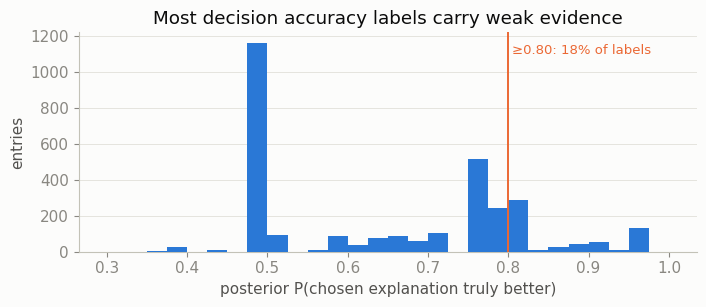

                                      mean P(chosen better)  entries
both_have_data_higher_accuracy                        0.801     1038
both_have_data_tied_more_samples                      0.501      482
only_first_has_data_above_threshold                   0.600      784
only_second_has_data_above_threshold                  0.605      787


In [37]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.hist(conf, bins=np.arange(0.30, 1.001, 0.025), color=PAL["blue"], zorder=3)
ax.axvline(0.8, color=PAL["orange"], linewidth=1.4, zorder=4)
ax.text(0.805, ax.get_ylim()[1]*0.9, f"≥0.80: {(conf>=0.8).mean():.0%} of labels",
        color=PAL["orange"], fontsize=9.5)
ax.set_xlabel("posterior P(chosen explanation truly better)")
ax.set_ylabel("entries")
ax.set_title("Most decision accuracy labels carry weak evidence")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

method = pd.Series({k: v["decision_method"] for k, v in hp.items()})
print(pd.DataFrame({"mean P(chosen better)": conf.groupby(method).mean().round(3),
                    "entries": method.value_counts()}))

**Takeaway:** only a small fraction of the 2,978 decision accuracy labels are statistically
trustworthy on their own. Any human-vs-LLM agreement analysis (and any reward-model training on
these labels) must weight by this confidence — which is what we do in §5. 

## 4. What do the LLM judges prefer?

Each entry was judged **once** by each of 3 models (Qwen, Gemma, Llama) — 3 total votes, no
within-model repetitions. So "LLM preference strength" has only two levels: unanimous (3–0) or
majority (2–1).

In [38]:
JUDGES = ["qwen", "gemma", "llama"]

vote_rows = []
for key, v in mp.items():
    srcs = {v["chosen_source"]} | {r["source"] for r in v["rejected_explanations"]}
    if len(srcs) == 1:      # same-source pair: judge vote is ill-defined
        continue
    pair = sorted(srcs)
    for j in JUDGES:
        vote_rows.append(dict(key=key, label=v["label"], judge=j,
                              vote_family=family(v["model_votes"][j]),
                              pair="/".join(sorted(family(s) for s in pair)),
                              unanimous=v["winning_votes"] == 3))
votes = pd.DataFrame(vote_rows)

print(f"votes: {len(votes):,} ({votes['key'].nunique():,} entries × 3 judges)")
print(f"unanimous entries: {votes.drop_duplicates('key')['unanimous'].mean():.1%}")

# pairwise inter-judge agreement
piv = votes.pivot(index="key", columns="judge", values="vote_family")
print("\npairwise judge agreement:")
for a, b in itertools.combinations(JUDGES, 2):
    print(f"  {a} vs {b}: {(piv[a] == piv[b]).mean():.3f}")

votes: 13,305 (4,435 entries × 3 judges)
unanimous entries: 53.8%

pairwise judge agreement:
  qwen vs gemma: 0.763
  qwen vs llama: 0.775
  gemma vs llama: 0.538


judge family  rate    n
gemma   base 0.208 3369
gemma claude 0.606 3154
gemma gemini 0.776 2347
llama   base 0.562 3369
llama claude 0.653 3154
llama gemini 0.206 2347
 qwen   base 0.394 3369
 qwen claude 0.619 3154
 qwen gemini 0.492 2347


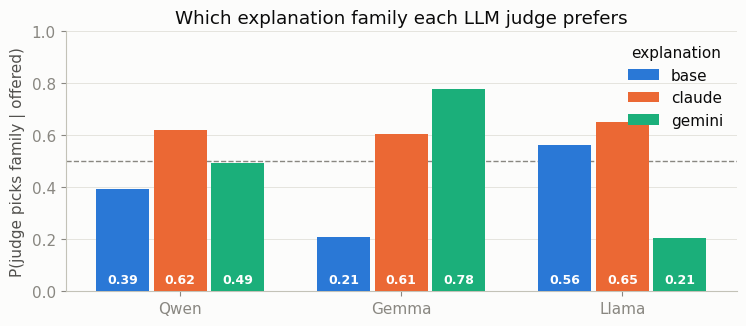

In [39]:
# For each judge: when family F was one of the two options, how often did the judge pick it?
appear, wins = collections.Counter(), collections.Counter()
for key, v in mp.items():
    srcs = {v["chosen_source"]} | {r["source"] for r in v["rejected_explanations"]}
    if len(srcs) == 1: continue
    fams_in_pair = [family(s) for s in srcs]
    for j in JUDGES:
        vf = family(v["model_votes"][j])
        for f in fams_in_pair:
            appear[(j, f)] += 1
            if f == vf: wins[(j, f)] += 1

pick = pd.DataFrame([dict(judge=j, family=f, rate=wins[(j, f)] / appear[(j, f)], n=appear[(j, f)])
                     for (j, f) in appear]).sort_values(["judge", "family"])
print(pick.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7.6, 3.4))
w = 0.24
for i, fam in enumerate(["base", "claude", "gemini"]):
    sub = pick[pick["family"] == fam].set_index("judge").loc[JUDGES]
    xs = np.arange(len(JUDGES)) + (i - 1) * (w + 0.02)
    ax.bar(xs, sub["rate"], width=w, color=FAMILY_COLOR[fam], label=fam, zorder=3)
    for x, y in zip(xs, sub["rate"]):
        ax.text(x, 0.03, f"{y:.2f}", ha="center", fontsize=9, color="#ffffff", fontweight="bold")
ax.axhline(0.5, color=MUTED, linewidth=1, linestyle="--")
ax.set_xticks(range(len(JUDGES))); ax.set_xticklabels([j.capitalize() for j in JUDGES])
ax.set_ylabel("P(judge picks family | offered)")
ax.set_ylim(0, 1)
ax.set_title("Which explanation family each LLM judge prefers")
ax.legend(title="explanation", frameon=False, loc="upper right")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### 4.1 Length bias check

LLM judges are notorious for preferring longer answers. We compare word counts of the chosen vs.
rejected explanation within each entry.

In [40]:
wc = lambda s: len(s.split())
len_rows = []
for key, v in mp.items():
    srcs = {v["chosen_source"]} | {r["source"] for r in v["rejected_explanations"]}
    if len(srcs) == 1: continue
    lc, lr = wc(v["chosen_explanation"]), wc(v["rejected_explanations"][0]["text"])
    len_rows.append(dict(key=key, len_chosen=lc, len_rejected=lr,
                         longer_won=lc > lr, tie=lc == lr, unanimous=v["winning_votes"] == 3))
L = pd.DataFrame(len_rows)
nt = L[~L["tie"]]
k, n = int(nt["longer_won"].sum()), len(nt)
lo, hi = wilson_ci(k, n)
print(f"LLM majority picked the LONGER explanation in {k/n:.1%} of non-tied entries [95% CI {lo:.1%}–{hi:.1%}] (n={n:,})")
print(f"median words — chosen: {L['len_chosen'].median():.0f}, rejected: {L['len_rejected'].median():.0f}")

# is length preference confounded with family? words per family:
fam_len = collections.defaultdict(list)
for key, v in mp.items():
    fam_len[family(v["chosen_source"])].append(wc(v["chosen_explanation"]))
    for r in v["rejected_explanations"]:
        fam_len[family(r["source"])].append(wc(r["text"]))
print("\nmedian explanation length by family (words):")
for f in ["base", "claude", "gemini"]:
    print(f"  {f:7s}: {np.median(fam_len[f]):.0f}")

LLM majority picked the LONGER explanation in 50.0% of non-tied entries [95% CI 48.5%–51.5%] (n=4,368)
median words — chosen: 61, rejected: 65

median explanation length by family (words):
  base   : 70
  claude : 65
  gemini : 47


## 5. Do LLM-judge preferences track what helped humans?

This is the core question for the baseline comparison: if LLM-as-judge preferences already predicted
decision-accuracy, RLHF-style training would be a strong baseline; if not, the decision-calibrated
reward has room to be useful.

We measure **agreement** = P(LLM majority choice == the explanation with the higher observed human
accuracy), over entries where both files describe the same well-defined pair (§1.2 exclusions applied).

**Which entries carry a real pairwise comparison?** In the 1,458 single-arm entries
(`only_first/second_has_data_above_threshold`) humans only ever saw *one* of the two explanations —
"chosen" just means that arm cleared 0.5, and carries **no pairwise information**. The primary
metric below therefore uses only the **both-arms entries** (`both_have_data_*`), where humans
actually generated evidence about both explanations; single-arm strata are reported for
completeness (expect them to sit symmetrically around chance).

Because even both-arms labels are mostly weak (§3), we also stratify by the posterior confidence of
the decision accuracy label — if judges track real signal, agreement should climb toward 1 as confidence climbs.

In [41]:
agree_rows = []
for key, v in hp.items():
    if key in EXCLUDE: continue
    m = mp[key]
    agree_rows.append(dict(key=key, label=v["label"],
                           agree=m["chosen_source"] == v["chosen_explanation_source"],
                           conf=conf[key], unanimous=m["winning_votes"] == 3,
                           method=v["decision_method"],
                           both_arms=v["decision_method"].startswith("both"),
                           n_total=v["chosen_decisions_count"] + v["rejected_decisions_count"]))
A = pd.DataFrame(agree_rows)
B = A[A["both_arms"]]           # PRIMARY: entries with a real pairwise human comparison

k, n = int(B["agree"].sum()), len(B)
lo, hi = wilson_ci(k, n)
print(f"PRIMARY — agreement on both-arms entries: {k/n:.3f} [95% CI {lo:.3f}–{hi:.3f}]  (n={n:,}; chance = 0.5)")
print()
print("strata (both-arms entries unless noted):")
for name, sub in [("LLM unanimous (3-0)", B[B["unanimous"]]),
                  ("LLM majority (2-1)", B[~B["unanimous"]]),
                  ("decision accuracy label conf ≥ 0.8", B[B["conf"] >= 0.8]),
                  ("decision accuracy label conf ≥ 0.9", B[B["conf"] >= 0.9]),
                  ("conf ≥ 0.8 AND unanimous", B[(B["conf"] >= 0.8) & B["unanimous"]])]:
    kk, nn = int(sub["agree"].sum()), len(sub)
    lo, hi = wilson_ci(kk, nn)
    print(f"  {name:28s}: {kk/nn:.3f} [{lo:.3f}–{hi:.3f}]  n={nn:,}")

print()
print("by decision_method (single-arm strata carry no pairwise info; shown for completeness):")
for name, sub in A.groupby("method"):
    kk, nn = int(sub["agree"].sum()), len(sub)
    lo, hi = wilson_ci(kk, nn)
    print(f"  {name:38s}: {kk/nn:.3f} [{lo:.3f}–{hi:.3f}]  n={nn:,}")

PRIMARY — agreement on both-arms entries: 0.467 [95% CI 0.442–0.493]  (n=1,491; chance = 0.5)

strata (both-arms entries unless noted):
  LLM unanimous (3-0)         : 0.428 [0.395–0.462]  n=815
  LLM majority (2-1)          : 0.515 [0.477–0.552]  n=676
  decision accuracy label conf ≥ 0.8: 0.485 [0.443–0.527]  n=530
  decision accuracy label conf ≥ 0.9: 0.510 [0.440–0.580]  n=194
  conf ≥ 0.8 AND unanimous    : 0.444 [0.387–0.503]  n=279

by decision_method (single-arm strata carry no pairwise info; shown for completeness):
  both_have_data_higher_accuracy        : 0.486 [0.455–0.516]  n=1,017
  both_have_data_tied_more_samples      : 0.428 [0.384–0.473]  n=474
  only_first_has_data_above_threshold   : 0.424 [0.389–0.459]  n=769
  only_second_has_data_above_threshold  : 0.527 [0.491–0.562]  n=771


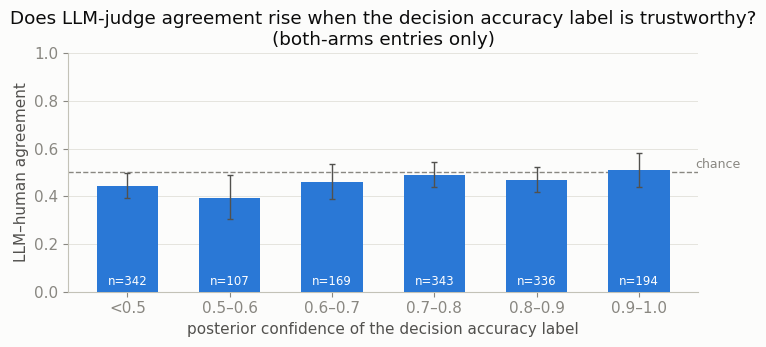

In [42]:
bins = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0001]
labels = ["<0.5", "0.5–0.6", "0.6–0.7", "0.7–0.8", "0.8–0.9", "0.9–1.0"]
B = B.copy()
B["conf_bin"] = pd.cut(B["conf"], bins=bins, labels=labels, right=False)

fig, ax = plt.subplots(figsize=(7.6, 3.6))
xs = np.arange(len(labels))
for x, lab in zip(xs, labels):
    sub = B[B["conf_bin"] == lab]
    if len(sub) == 0: continue
    kk, nn = int(sub["agree"].sum()), len(sub)
    p = kk / nn; lo, hi = wilson_ci(kk, nn)
    ax.bar(x, p, width=0.6, color=PAL["blue"], zorder=3)
    ax.errorbar(x, p, yerr=[[p - lo], [hi - p]], fmt="none", ecolor=INK2, elinewidth=1, capsize=2, zorder=4)
    ax.text(x, 0.03, f"n={nn:,}", ha="center", fontsize=8.5, color="#ffffff")
ax.axhline(0.5, color=MUTED, linestyle="--", linewidth=1)
ax.text(len(labels) - 0.45, 0.505, "chance", fontsize=9, color=MUTED, va="bottom")
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_xlabel("posterior confidence of the decision accuracy label")
ax.set_ylabel("LLM–human agreement")
ax.set_ylim(0, 1)
ax.set_title("Does LLM-judge agreement rise when the decision accuracy label is trustworthy?\n(both-arms entries only)")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### 5.1 Source-level comparison (robust to item-level noise)

Item-level labels are noisy, but pooling by source directory gives well-powered estimates on both
sides: **pooled human accuracy** per source vs. the **LLM-judge win rate** per source (share of
pairwise matchups won when offered). If judges track decision-accuracy, sources should line up.

In [43]:
# human pooled accuracy per source dir
hum_src = d.groupby("source").apply(pooled, include_groups=False)

# LLM win rate per source dir (majority vote), over well-defined pairs
ap, wn = collections.Counter(), collections.Counter()
for key, v in mp.items():
    srcs = {v["chosen_source"]} | {r["source"] for r in v["rejected_explanations"]}
    if len(srcs) == 1: continue
    for s in srcs:
        ap[s] += 1
        if s == v["chosen_source"]: wn[s] += 1
llm_src = pd.DataFrame({s: dict(win_rate=wn[s] / ap[s], n_matchups=ap[s]) for s in ap}).T

cmp_src = hum_src.join(llm_src)
cmp_src["family"] = [family(s) for s in cmp_src.index]
cmp_src["text_type"] = ["Human-written" if "Reddit" in s else "AI-written" for s in cmp_src.index]
print(cmp_src[["family", "text_type", "acc", "n", "win_rate", "n_matchups"]].round(3)
      .sort_values(["text_type", "family"]).to_string())

r_all = stats.spearmanr(cmp_src["acc"], cmp_src["win_rate"])
print(f"\nSpearman rank correlation across the 6 sources: rho={r_all.statistic:.2f} (p={r_all.pvalue:.2f})")
for side in ["Human-written", "AI-written"]:
    sub = cmp_src[cmp_src["text_type"] == side]
    print(f"  within {side} texts (3 sources): human ranking {list(sub.sort_values('acc', ascending=False)['family'])} "
          f"vs LLM ranking {list(sub.sort_values('win_rate', ascending=False)['family'])}")

                                        family      text_type    acc       n  win_rate  n_matchups
source                                                                                            
SocialMedia_rewrite_explanation           base     AI-written  0.573  1703.0     0.382      1617.0
SocialMedia_rewrite_explanation_claude  claude     AI-written  0.530  1771.0     0.604      1725.0
SocialMedia_rewrite_explanation_gemini  gemini     AI-written  0.543  1083.0     0.510      1100.0
SocialMedia_Reddit_explanation            base  Human-written  0.601  1882.0     0.405      1752.0
SocialMedia_Reddit_explanation_claude   claude  Human-written  0.600  1524.0     0.638      1429.0
SocialMedia_Reddit_explanation_gemini   gemini  Human-written  0.612  1398.0     0.476      1247.0

Spearman rank correlation across the 6 sources: rho=-0.31 (p=0.54)
  within Human-written texts (3 sources): human ranking ['gemini', 'base', 'claude'] vs LLM ranking ['claude', 'gemini', 'base']
  within AI

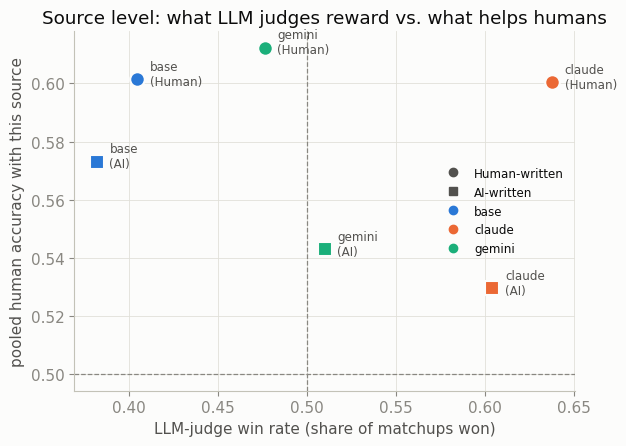

In [44]:
fig, ax = plt.subplots(figsize=(6.4, 4.6))
markers = {"Human-written": "o", "AI-written": "s"}
for _, r in cmp_src.iterrows():
    ax.scatter(r["win_rate"], r["acc"], s=110, color=FAMILY_COLOR[r["family"]],
               marker=markers[r["text_type"]], zorder=4,
               edgecolors=SURFACE, linewidths=1.5)
    ax.annotate(f"{r['family']}\n({r['text_type'].split('-')[0]})",
                (r["win_rate"], r["acc"]), textcoords="offset points", xytext=(9, -4),
                fontsize=8.6, color=INK2)
ax.axhline(0.5, color=MUTED, linestyle="--", linewidth=0.9)
ax.axvline(0.5, color=MUTED, linestyle="--", linewidth=0.9)
ax.set_xlabel("LLM-judge win rate (share of matchups won)")
ax.set_ylabel("pooled human accuracy with this source")
ax.set_title("Source level: what LLM judges reward vs. what helps humans")
handles = [plt.Line2D([], [], marker=m, linestyle="", color=INK2, label=l) for l, m in markers.items()]
handles += [plt.Line2D([], [], marker="o", linestyle="", color=c, label=f) for f, c in FAMILY_COLOR.items()]
ax.legend(handles=handles, frameon=False, fontsize=8.6, loc="best")
plt.tight_layout(); plt.show()